## Importing Required Libraries

In this step, we import all the necessary Python libraries that are required for data analysis, visualization, machine learning, and time-series forecasting.

- **Pandas** is used for data manipulation and analysis.
- **NumPy** is used for numerical computations.
- **Matplotlib** is used for data visualization and plotting graphs.
- **Seaborn** is used to enhance the visual appearance of plots.
- **Scikit-learn** provides the Linear Regression model for predictive analysis.
- **Statsmodels** provides the Exponential Smoothing model for time-series forecasting.

These libraries form the foundation of our sales forecasting system.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import seaborn as sns
sns.set_style('darkgrid')

## Loading the Dataset




In [3]:

df = pd.read_csv('Sales_dataset.csv', parse_dates=['Date'])




## Daily Sales Aggregation and Visualization

In this step, the dataset is grouped by date to calculate the total sales for each day.  
This aggregation helps in analyzing overall daily sales trends by combining sales from all stores and products.

A line plot is then created to visualize how total daily sales change over time.  
The graph clearly shows sales patterns, trends, and fluctuations across different dates, making it suitable for time-series analysis and forecasting.


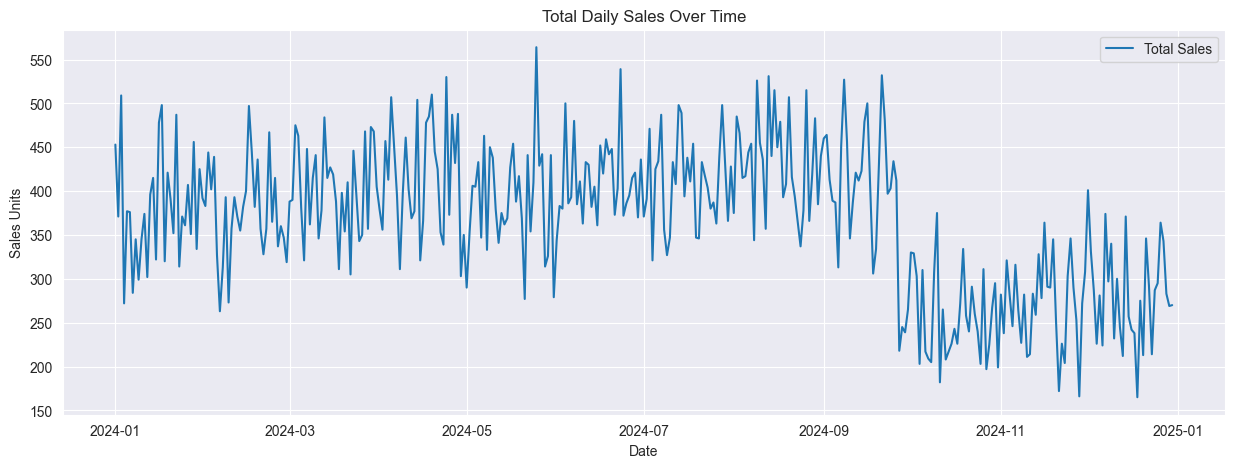

In [4]:
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()
plt.figure(figsize=(15,5))
plt.plot(daily_sales['Date'], daily_sales['Sales'], label='Total Sales')
plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales Units')
plt.legend()
plt.show()

In [5]:
daily_sales.head()

,Date,Sales
0,2024-01-01,453
1,2024-01-02,371
2,2024-01-03,509
3,2024-01-04,272
4,2024-01-05,377


## Preparing Data for Regression Analysis

In this step, the dataset is first sorted based on the Date column to ensure the correct chronological order of records.  
Sorting is important because regression and time-series models rely on properly ordered data.

The Date column is then converted into a numeric format called **Day**, which represents the number of days passed since the start of the dataset.  
This conversion is necessary because machine learning models cannot directly work with datetime values.

After that, the data is grouped by the Day column to calculate total daily sales.  
Finally, the dataset is divided into:
- **X (independent variable):** Day  
- **y (dependent variable):** Sales  

This prepared data is now ready to be used in a Linear Regression model.


In [6]:

df_sorted = df.sort_values('Date')

df_sorted['Day'] = (df_sorted['Date'] - df_sorted['Date'].min()).dt.days

daily_sales_reg = df_sorted.groupby('Day')['Sales'].sum().reset_index()
X = daily_sales_reg[['Day']]  
y = daily_sales_reg['Sales']



In [8]:
print (X.head())
print (y.head())


   Day
0    0
1    1
2    2
3    3
4    4
0    453
1    371
2    509
3    272
4    377
Name: Sales, dtype: int64


In [40]:
df_sorted.head(10)

,Date,Store,Product,Sales,Price,Promotion,Holiday,Inventory,Weekday,Month,Day
0,2024-01-01,Store 3,Product C,140,15,1,0,444,Monday,Jan,0
730,2024-01-01,Store 3,Product E,200,19,1,0,469,Monday,Jan,0
365,2024-01-01,Store 2,Product A,113,10,0,0,467,Monday,Jan,0
1,2024-01-02,Store 1,Product C,123,15,0,0,370,Tuesday,Jan,1
731,2024-01-02,Store 1,Product D,99,7,0,0,332,Tuesday,Jan,1
366,2024-01-02,Store 2,Product C,149,14,1,0,372,Tuesday,Jan,1
2,2024-01-03,Store 3,Product E,149,20,0,0,406,Wednesday,Jan,2
732,2024-01-03,Store 2,Product E,206,20,1,0,311,Wednesday,Jan,2
367,2024-01-03,Store 3,Product C,154,16,1,0,375,Wednesday,Jan,2
3,2024-01-04,Store 3,Product D,78,9,1,0,349,Thursday,Jan,3


## Linear Regression Model Training and Prediction

In this step, a Linear Regression model is trained to understand the relationship between time (represented by the Day variable) and total daily sales.

The model is trained using:
- **X (independent variable):** Day  
- **y (dependent variable):** Sales  

After training the model, it is used to predict sales values based on the learned trend.  
These predicted values represent the regression line fitted to the historical sales data.

A line plot is then created to compare:
- **Actual Sales** (real observed values)
- **Predicted Sales** (values estimated by the regression model)

This visualization helps in understanding how well the linear regression model fits the sales data.


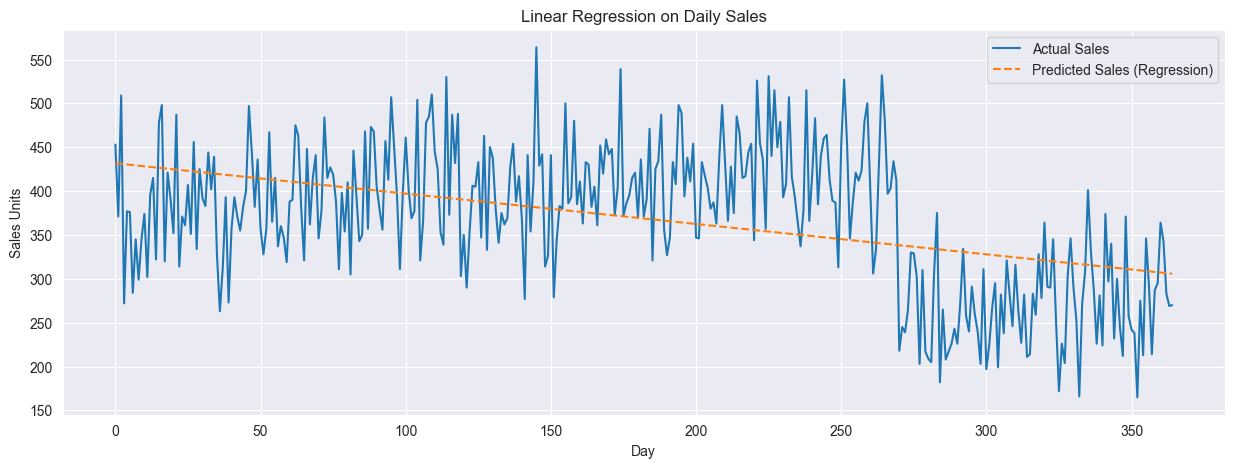

In [52]:

model = LinearRegression()
model.fit(X, y)

# Predict sales
daily_sales_reg['Predicted_Sales'] = model.predict(X)

# Plot regression results
plt.figure(figsize=(15,5))
plt.plot(daily_sales_reg['Day'], daily_sales_reg['Sales'], label='Actual Sales')
plt.plot(daily_sales_reg['Day'], daily_sales_reg['Predicted_Sales'], linestyle='--', label='Predicted Sales (Regression)')
plt.title('Linear Regression on Daily Sales')
plt.xlabel('Day')
plt.ylabel('Sales Units')
plt.legend()
plt.show()


In [53]:
daily_sales_reg.head()

,Day,Sales,Predicted_Sales
0,0,453,431.707164
1,1,371,431.361159
2,2,509,431.015154
3,3,272,430.669149
4,4,377,430.323144


## Creating Time-Series Data

In this step, the daily sales DataFrame is converted into a time-series format.  
The Date column is set as the index, and only the Sales values are selected.

This transformation is important because time-series forecasting models require:
- **Date as the index**
- **Sales as the time-dependent values**

The resulting time-series data is then used for advanced forecasting techniques such as Exponential Smoothing.


In [55]:
ts_sales = daily_sales.set_index('Date')['Sales']

In [56]:
ts_sales.head()

Date
2024-01-01    453
2024-01-02    371
2024-01-03    509
2024-01-04    272
2024-01-05    377
Name: Sales, dtype: int64

## Exponential Smoothing Forecasting

In this step, an Exponential Smoothing time-series model is applied to the daily sales data to forecast future sales.

The model is configured with:
- **Additive trend**, to capture overall upward or downward movement in sales.
- **Additive seasonality**, to capture repeating patterns in the data.
- **Seasonal period of 7**, assuming a weekly sales pattern in daily data.

After fitting the model to historical sales data, future sales are forecasted for the next 90 days.

A line plot is then used to visualize:
- **Actual Sales** (historical data)
- **Forecasted Sales** (future predictions generated by the model)

This visualization helps in understanding future sales behavior and comparing it with past trends.


c:\Users\TECH CLUB\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


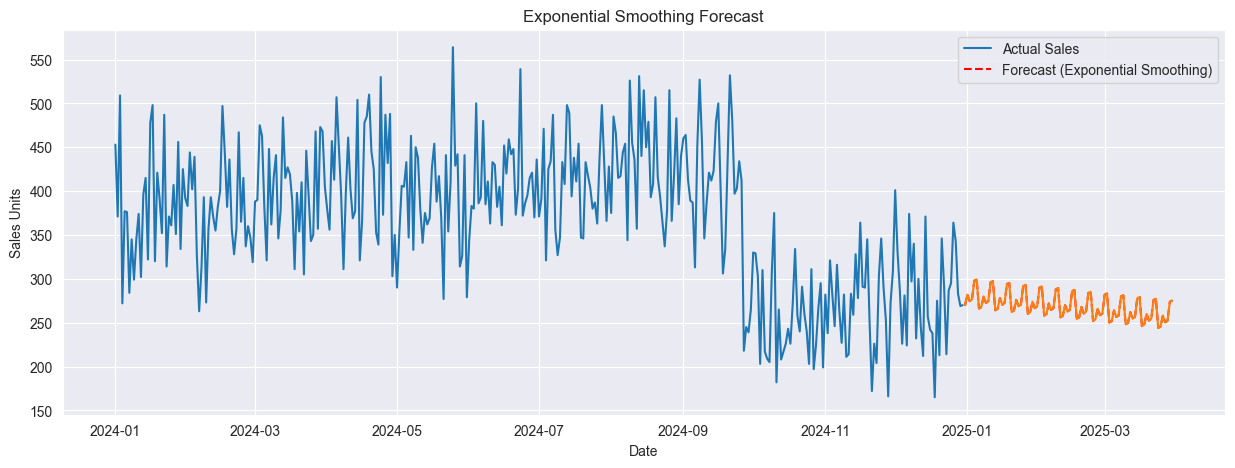

In [62]:
model_es = ExponentialSmoothing(ts_sales, trend='add', seasonal='add', seasonal_periods=7)
fit_es = model_es.fit()

# Forecast next 30 days
forecast_es = fit_es.forecast(90)

# Plot
plt.figure(figsize=(15,5))
plt.plot(ts_sales.index, ts_sales, label='Actual Sales')
plt.plot(forecast_es.index, forecast_es, linestyle='--', color='red', label='Forecast (Exponential Smoothing)')
plt.plot(forecast_es.index, forecast_es)

plt.title('Exponential Smoothing Forecast')
plt.xlabel('Date')
plt.ylabel('Sales Units')
plt.legend()
plt.show()

## Final Comparison: Actual Sales vs Regression vs Exponential Smoothing

In this step, a final comparison graph is created to visualize and compare the performance of different forecasting approaches on the same timeline.

The plot includes:
- **Actual Sales:** Historical daily sales data plotted against real dates.
- **Linear Regression Prediction:** Regression-based sales estimates fitted on past data to capture the overall sales trend.
- **Exponential Smoothing Forecast:** Future sales predictions generated using the Exponential Smoothing model, which accounts for both trend and seasonality.

All values are plotted using the **Date** on the X-axis to ensure proper alignment and clear interpretation of results.  
This comparison helps in understanding the difference between simple regression-based trends and advanced time-series forecasting models, as well as their ability to predict future sales behavior.


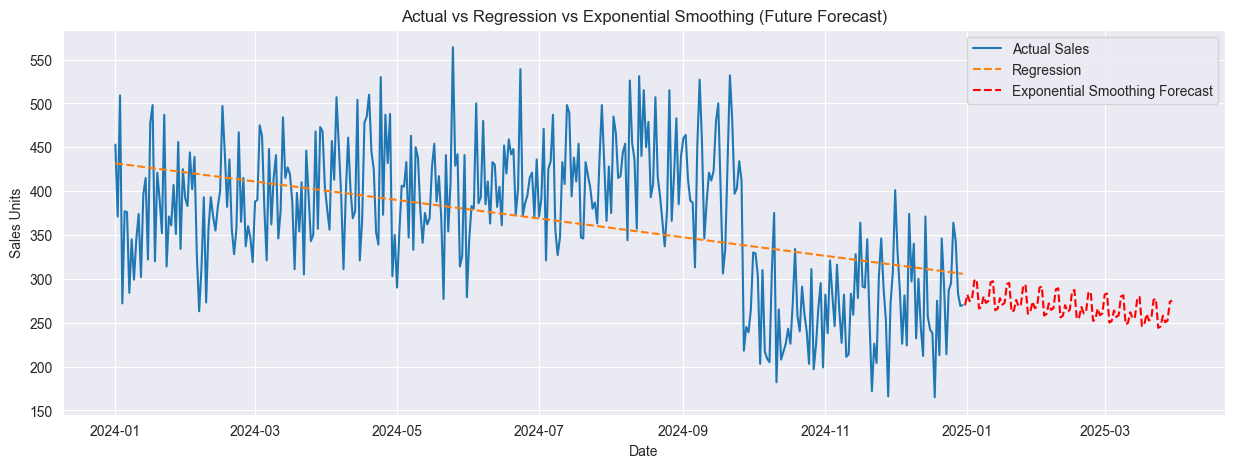

In [ ]:
plt.figure(figsize=(15,5))

# Actual Sales
plt.plot(daily_sales['Date'],
         daily_sales['Sales'],
         label='Actual Sales')

# Regression Prediction 
plt.plot(daily_sales['Date'],
         daily_sales_reg['Predicted_Sales'],
         linestyle='--',
         label='Regression')

#  Exponential Smoothing FUTURE Forecast
plt.plot(forecast_es.index,
         forecast_es,
         linestyle='--',
         color='red',
         label='Exponential Smoothing Forecast')

plt.title('Actual vs Regression vs Exponential Smoothing (Future Forecast)')
plt.xlabel('Date')
plt.ylabel('Sales Units')
plt.legend()
plt.show()
